# Fetching Breast Cancer Dataset


_______________________________________________________________________________________

This Jupyter Notebook calls the "Breast Cancer Wisconsin (Original)" dataset from the UCI Machine Learning Repo found here: http://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original. The Breast Cancer dataset is a 9 - feature dataset with 699 instances and contains 2 classes of data. The Features of the dataset are 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', and 'Mitoses', which are all on an integer scale from 1-10. The class instances are '2', which indicates benign, and '4' which indicates malignant.

In this code, I reformat the dataframe to hold two new columns for 'Clump_thickness' and 'Uniformity_of_cell_size' which are min-max scaled to fit on the interval $\in (0,1)$. These scaled columns are stored in 'Clump_thickness scaled' and	'Uniformity_of_cell_size scaled' respectively. Additionally, 2 more columns are appended called 'target' and 'binary target'. 'target' holds the classifications as described by the original dataset in terms of either a '2' or '4'. Whereas 'target binary' maps these classification onto binary variables such that $'2' \rightarrow 0$ and $'4' \rightarrow 1$. Thus, ideally, our trained binary classifier will return *0* for a patient with benign breast cancer and will return *1* for a patient with malignant breast cancer.

After plotting the data, we see that because 'Clump_thickness' and 'Uniformity_of_cell_size' are only on a 1-10 integer scale, there is many instances of overlap and non-linear seperability of the data. Thus, this dataset is intended to be a more difficult benchmark of a classification task as compared to the 'iris' data. After compiling, the Jupyter Notebook returns a file called 'breast_cancer_dataset.csv' to be imported in *QNN_breast_cancer.ipynb*.

__________________________________________________________________________________________________
[1] A. Daskin, “A simple quantum neural net with a periodic activation function,” 2018 IEEE International Conference on Systems, Man, and Cybernetics (SMC), Oct. 2018. doi:10.1109/smc.2018.00491 

In [2]:
# Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ucimlrepo import fetch_ucirepo 

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [1]:
# Defining Functions

def MinMax_Scaling(df, feature_name):
    '''
    Function Description:
    Scales Data in a Pandas dataframe to a [0,1] interval using Min-Max scaling
    and returns an updated data frame with a new column of the scaled feature
    
    Params:
    - df            : A Pandas Dataframe
    - feature_name : A type string of the feature in the dataframe you want to Min-Max scale
    '''

    x = np.array(df[feature_name])
    
    x_scaled = (x-min(x))/(max(x) - min(x))  # Min - Max Scaling of user-specified feature

    df[feature_name + " scaled"] = x_scaled # Updating the dataframe with a new column of the scaled variable

    return df

In [5]:
# Fetching Dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 

df = breast_cancer_wisconsin_original.data.features     # Making a Pandas Dataframe of Breast Cancer Features
num_data = len(df)                                      # Counting Number of Data points



df["targets"] = breast_cancer_wisconsin_original.data.targets   # Appending a column with cancer diagnosis

# Assigning binary class labels: If '2'(benign)->0, else if '4'(malignant) -> 1
binary_targets = []
targets = df["targets"]
for i in range(num_data):
    if targets[i] == 2: 
        binary_targets.append(0)
    elif targets[i] == 4: 
        binary_targets.append(1)

# Adding Binary Labelings to the Dataframe
df["Class"] = binary_targets

del binary_targets

df = df.sample(frac=1) # Randomly Shuffling around data

df=df.drop(columns="targets")
df # Displaying dataframe

/var/folders/qr/xclfb4t95slf35bqbh0gd_400000gn/T/ipykernel_14241/3583123327.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["targets"] = breast_cancer_wisconsin_original.data.targets   # Appending a column with cancer diagnosis


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
88,4,1,1,1,2,1.0,3,1,1,0
54,10,5,5,6,8,8.0,7,1,1,1
626,4,6,6,5,7,6.0,7,7,3,1
666,5,2,2,2,2,1.0,1,1,2,0
355,4,1,1,1,3,1.0,2,2,1,0
...,...,...,...,...,...,...,...,...,...,...
310,2,1,1,1,3,1.0,2,1,1,0
200,9,7,7,5,5,10.0,7,8,3,1
56,8,10,10,1,3,6.0,3,9,1,1
23,8,4,5,1,2,NaN,7,3,1,1


In [6]:
df.to_csv('breast_cancer_original.csv', index = False)

Explained variance by each component: [0.65549993 0.08621632]
Total variance retained: 0.7417162482831765


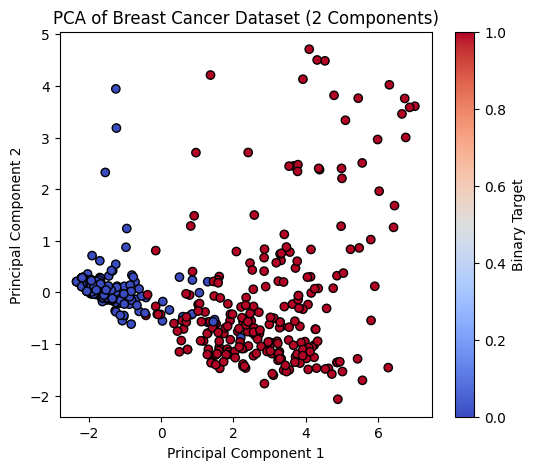

,PC1,PC2,binary targets
0,3.716100,0.471131,1
1,-1.033929,-0.477719,0
2,-1.577335,-0.054321,0
3,2.210969,-0.283587,1
4,1.906575,-0.547595,1


In [5]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Assuming your dataframe is named 'df'
# Drop rows with missing values
df_clean = df.dropna()

# Select only numeric feature columns (exclude target labels)
feature_cols = [
    'Clump_thickness',
    'Uniformity_of_cell_size',
    'Uniformity_of_cell_shape',
    'Marginal_adhesion',
    'Single_epithelial_cell_size',
    'Bare_nuclei',
    'Bland_chromatin',
    'Normal_nucleoli',
    'Mitoses'
]

X = df_clean[feature_cols]
y = df_clean["binary targets"]

# Standardize features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a new dataframe with principal components
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['binary targets'] = y.values

# Display explained variance ratio
print("Explained variance by each component:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

# Visualize the two components
plt.figure(figsize=(6,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['binary targets'], cmap='coolwarm', edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Breast Cancer Dataset (2 Components)')
plt.colorbar(label='Binary Target')
plt.show()

# Optional: show transformed data
pca_df.head()


In [6]:
import pickle

# Save the scaler fitted on your training data
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save the fitted PCA
pickle.dump(pca, open("pca_model.pkl", "wb"))


In [7]:
pca_df.to_csv('breast_cancer_dataset_pca.csv', index = False)

# Supervised Autoencoder

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np


In [8]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [9]:
class SupervisedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(9, 6),
            nn.ReLU(),
            nn.Linear(6, 2)   # 🔑 2D bottleneck
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 6),
            nn.ReLU(),
            nn.Linear(6, 9)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        y_pred = self.classifier(z)
        return z, x_recon, y_pred


In [26]:
model = SupervisedAutoencoder()

recon_loss_fn = nn.MSELoss()
clf_loss_fn = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

lambda_clf = 1.5  # balance parameter


In [27]:
epochs = 100

for epoch in range(epochs):
    total_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()

        z, x_recon, y_pred = model(xb)

        recon_loss = recon_loss_fn(x_recon, xb)
        clf_loss = clf_loss_fn(y_pred, yb)

        loss = recon_loss + lambda_clf * clf_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")


Epoch 10/100, Loss: 26.0671
Epoch 20/100, Loss: 10.7892
Epoch 30/100, Loss: 10.2685
Epoch 40/100, Loss: 9.7317
Epoch 50/100, Loss: 9.0569
Epoch 60/100, Loss: 8.7984
Epoch 70/100, Loss: 8.3435
Epoch 80/100, Loss: 8.2005
Epoch 90/100, Loss: 8.1215
Epoch 100/100, Loss: 8.1732


In [28]:
model.eval()
with torch.no_grad():
    Z_latent = model.encoder(X_tensor).numpy()


In [31]:
latent_df = pd.DataFrame(
    Z_latent,
    columns=["feature_1", "feature_2"]
)

latent_df["binary_target"] = y.values


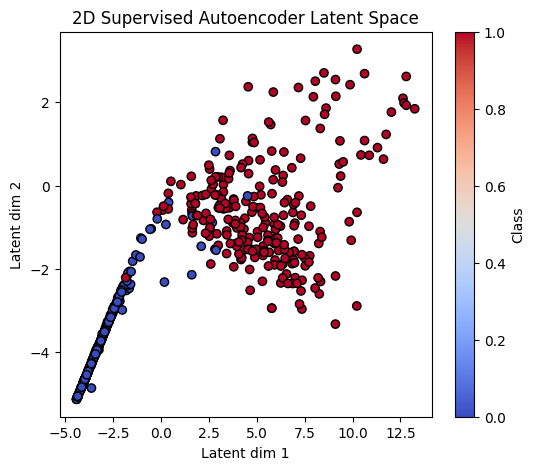

In [29]:
import matplotlib.pyplot as plt

Z = Z_latent

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=y.values, cmap='coolwarm', edgecolors='k')
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")
plt.title("2D Supervised Autoencoder Latent Space")
plt.colorbar(label="Class")
plt.show()


In [30]:
with torch.no_grad():
    z, _, y_pred = model(X_tensor)
    preds = (y_pred > 0.5).float()
    acc = (preds == y_tensor).float().mean()
    print("Training accuracy:", acc.item())


Training accuracy: 0.9765739440917969


In [ ]:
latent_df

,feature_1,feature_2,binary_target
0,1.630346,-1.130365,1
1,5.579721,-1.188486,1
2,4.763352,1.045804,1
3,4.565992,0.602009,1
4,-2.448040,-2.953876,0
...,...,...,...
678,-4.355334,-5.054643,0
679,7.100257,-2.344009,1
680,-4.355334,-5.054643,0
681,11.612568,0.638327,1


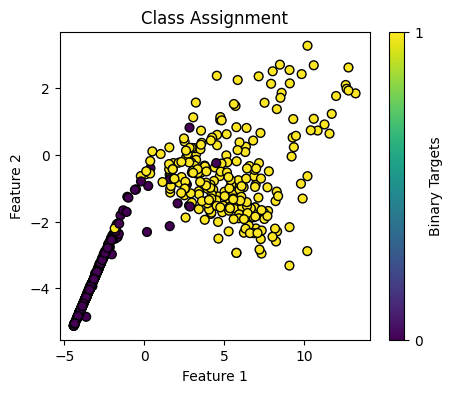

In [34]:
# Data Visualization


# Calling clump thickness scaled, uniformity of cell size scaled, and binary class assignment
f1         = latent_df["feature_1"].values
f2 = latent_df["feature_2"].values
binary_target = latent_df["binary_target"]


# Plotting Uniformity of cell size vs clump thickness and their class assignment
plt.figure(figsize=(5,4))
plt.title('Class Assignment')
plt.scatter(f1, f2, c = binary_target, edgecolors='black', s = 40)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Binary Targets', ticks=[0, 1]) 
plt.show()

In [35]:
# Exporting the Dataframe to a csv file
latent_df.to_csv('breast_cancer_dataset_postprocessing.csv', index = False)

# Making a Parameterized Quantum Circuit (PQC) in Qiskit



____________________________________________________________________________________________________


This Jupyter Notebook constucts the Parameterized Quantum Circuit described in *Figure 1* in [1] in the Qiskit framework. Here, I prototype a PQC with 2 feature inputs $\vec{x} = (x_{0},x_{1})$ and 4 model weights $\vec{\omega} = (\omega_{0}, \omega_{1}, \omega_{2}, \omega_{3})$.


We start with encoding the unitary $U$. Recognizing that $U$ is a diagonal unitary with eigenvalues of phase $\alpha_{i}$, I can accomplish a gate composition of $U$ using $X$-Gates and control-phase gates. I utilize **ParameterVector** from Qiskit to keep these $\alpha_{i}$ values arbiitrary, so we can update them later on. Each $\alpha_{i}$ is defined as a linear combination of elements in $\vec{x}$ and $\vec{\omega}$. Then I apply the *U.control(1)* function to map $U$ to a *Controlled*-$U$ gate.

After defining the *Controlled*-$U$ gate, I begin building the Parameterized Quantum Circuit by first applying a Hadamard to all qubits, then a *Controlled*-$U$ gate, where the classifier qubit is the control qubit and the computational qubits are the target qubits. After this, a Hadamard gate is applied to the classifier qubit, which acts as an activation function. Then, the classifier qubit is measured.

The PQC is exported as a *.qpy* file called *parameterized_qc.qpy* to be later imported and used in *3.1 QNN_iris.ipynb*, *3.2 QNN_breast_cancer.ipynb*, and *QNN_MNIST.ipynb*.
_____________________________________________________________________________

[1] A. Daskin, “A simple quantum neural net with a periodic activation function,” 2018 IEEE International Conference on Systems, Man, and Cybernetics (SMC), Oct. 2018. doi:10.1109/smc.2018.00491 

In [3]:
# Importing Packages
from qiskit.circuit import Parameter
from qiskit.quantum_info import Operator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile, qpy

In [37]:
# Making a Parameterized Controlled - U Operation

U = QuantumCircuit(2, name='U')
# ===========================
# Defining Parameters
x     = ParameterVector('x', 2)
omega = ParameterVector('w', 4)
# ===========================
# Phase Encoding on |00> State
U.x(0)
U.x(1)
U.cp(x[0]*omega[0] + x[1]*omega[2] ,0,1)
U.x(0)
U.x(1)
# ===========================
# Phase Encoding on the |01> State
U.x(0)
U.cp(x[0]*omega[0] + x[1]*omega[3],0,1)
U.x(0)
# ===========================
# Phase Encoding on the |10> State
U.x(1)
U.cp(x[0]*omega[1] + x[1] * omega[2],0,1)
U.x(1)
# ===========================
# Phase Encoding on the |11> State
U.cp(x[0]*omega[1] + x[1]*omega[3],0,1)
# ===========================
# Transpiling Circuit
U = transpile(U)

# ===========================
# Mapping to Qiskit Gates

# Mapping to 2 Qubit Unitary
U_gate = U.to_gate()

# Mapping to Control 2 Qubit Unitary
CU_gate = U.control(1)

In [38]:
# Drawing the U Gate
U.draw()

┌───┐                                                           ┌───┐»
q_0: ┤ X ├─■───────────────────────────────■─────────────────────────┤ X ├»
     ├───┤ │P(w[0]*x[0] + w[2]*x[1]) ┌───┐ │P(w[0]*x[0] + w[3]*x[1]) ├───┤»
q_1: ┤ X ├─■─────────────────────────┤ X ├─■─────────────────────────┤ X ├»
     └───┘                           └───┘                           └───┘»
«                                                                
«q_0: ─■───────────────────────────────■─────────────────────────
«      │P(w[1]*x[0] + w[2]*x[1]) ┌───┐ │P(w[1]*x[0] + w[3]*x[1]) 
«q_1: ─■─────────────────────────┤ X ├─■─────────────────────────
«                                └───┘

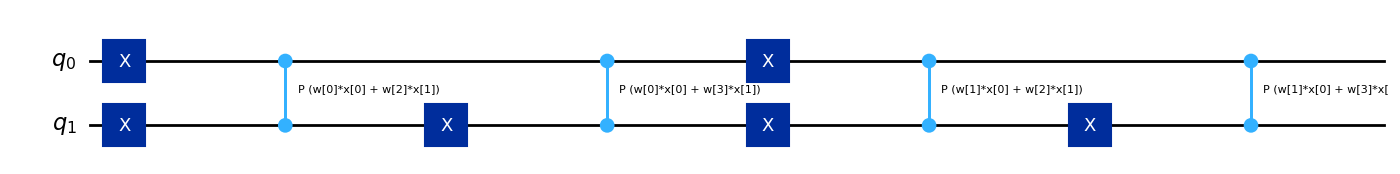

In [40]:
U.draw(output='mpl')

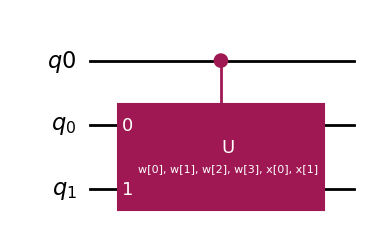

In [41]:
# Drawing the CU Gate
CU_gate.draw("mpl")

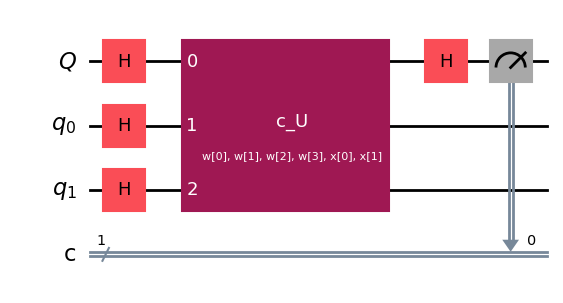

In [42]:
# Constructing the Parameterized Quantum Circuit

# ===============================================
# Specifying number of qubits in each register

num_classifier_qubits    = 1
num_computational_qubits = 2
num_qubits = num_classifier_qubits + num_computational_qubits

# ===============================================
# Initializing Registers & Quantum Circuit

q_class =  QuantumRegister(num_classifier_qubits   , name = 'Q')
q_comp  =  QuantumRegister(num_computational_qubits, name = 'q')
c       =  ClassicalRegister(1, name = 'c')
qc      =  QuantumCircuit(q_class,q_comp,c,name = 'qc')

# ===============================================
# Prototyping Quantum Gates

# Classifier Qubit gets initialized by a Hadamard
qc.h(q_class[0])

# Choosing our computational qubits to start in the equal coherent superposition state
qc.h(q_comp[0])
qc.h(q_comp[1])

# Applying a control Unitary
qc.append(CU_gate,[q_class[0],q_comp[0],q_comp[1]])

# Applying the Hadamard on classifier qubit as an activation function
qc.h(q_class[0])


# Measuring The Classifier Qubit
qc.measure(q_class[0], c[0])

# ===============================================
# Drawing Quantum Circuit
qc.draw("mpl")

In [43]:
# Exporting the Parameterized Quantum Circuit 'qc' as a .qpy file

with open("parameterized_qc.qpy", "wb") as qpy_file_write:
    qpy.dump(qc, qpy_file_write)

# Quantum Neural Network for Binary Classification of Breast Cancer Data


_______________________________________________________________________________________________________________



This Jupyter Notebook accomplishes the following tasks:
- Imports 'breast_cancer_dataset.csv', and splits & formats data into training & testing data
- Trains parameters on Quantum Neural Network model to perform binary classification
- Trains parameters on Convolutional Neural Network model to perform binary classification

The specifics of each task are outlined in more detail each corresponding subsection below.

In [44]:
#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qiskit.circuit import Parameter
from qiskit.quantum_info import Operator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile, qpy

# Custom Packages
import Qfuncs5 as qf                                    # My own custom Qiskit Package
from QuantumNeuralNetwork import QuantumNeuralNetwork   # Custom Made QNN Trainer for our PQC
from NeuralNetScore import nn_confusion                 # Generate confusion matrix for neural net binary classifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import plot_model


# Setting a Random Seed For Reproducability
np.random.seed(224)

2026-01-18 22:51:47.301770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Importing 'breast_cancer_dataset.csv'

Here, we use pandas to import the 'breast_cancer_dataset.csv' file.

We then gather the 'Clump_thickness scaled', and 'Uniformity_of_cell_size scaled' as our two feature variables $x_{0}$, $x_{1}$, and extract their associated class labels by calling the 'binary targets' column.

Next, we split the dataset such that the first 17% of the data is training data and the last 83% is testing data.

In [2]:
#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qiskit.circuit import Parameter
from qiskit.quantum_info import Operator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile, qpy

# Custom Packages
import Qfuncs5 as qf                                    # My own custom Qiskit Package
from QuantumNeuralNetwork import QuantumNeuralNetwork   # Custom Made QNN Trainer for our PQC
from NeuralNetScore import nn_confusion                 # Generate confusion matrix for neural net binary classifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import plot_model


# Setting a Random Seed For Reproducability
np.random.seed(224)

/var/folders/qr/xclfb4t95slf35bqbh0gd_400000gn/T/ipykernel_5940/2822184523.py:6: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit.circuit import Parameter
2026-01-20 21:43:58.535675: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
# Importing 'breast_cancer_dataset.csv'
df = pd.read_csv('breast_cancer_dataset_pca.csv')

# Displaying Pandas DataFrame
df

,PC1,PC2,binary targets
0,4.327890,-0.947624,1
1,-1.825741,0.088804,0
2,-1.923833,0.170510,0
3,-1.413018,-0.004279,0
4,-1.825741,0.088804,0
...,...,...,...
678,3.661631,2.448809,1
679,-1.563800,0.065358,0
680,1.559853,0.241160,1
681,-2.040069,0.188709,0


In [7]:
# Gathering Data from Dataframe
X = df[["PC1" , "PC2"]].values
binary_targets = df["binary targets"].values

# Partitioning Training Data
x_train = X[:120] # :120
binary_targets_train = binary_targets[:120]

# Partitioning Testing Data
x_test = X[120:]
binary_targets_test = binary_targets[120:]


# Loading in Parameterized Quantum Circuit and Training the Quantum Neural Network

Here, we load in our parameterized quantum circuit file 'parameterized_qc.qpy' and read it as a Qiskit *QuantumCircuit* class and draw the circuit to confirm that the PQC loaded in without any errors.

Next, we define QNN as a QuantumNeuralNetwork class, specify the number of epochs and learning rate, then use QuantumNeuralNetwork.train() to train the model parameters and assess model performance.

After, we can use QuantumNeuralNetwork.get() to retrieve the updated model parameters, QuantumNeuralNetwork.confusion_matrix() to assess model error, and QuantumNeuralNetwork.learning_graph() to plot the objective function as a function of epoch.

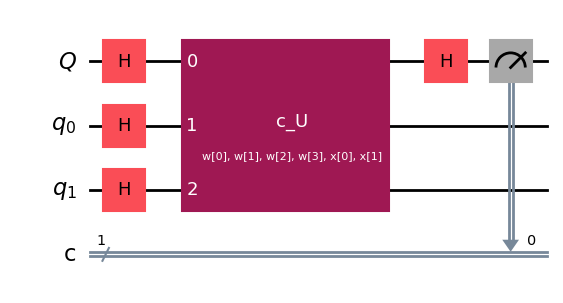

In [48]:
# Loading in the PQC
with open("parameterized_qc.qpy", "rb") as qpy_file_read:
    qc = qpy.load(qpy_file_read)[0]

qc.draw("mpl")

In [ ]:
# Building Quantum Neural Network
QNN = QuantumNeuralNetwork(qc,x_train, binary_targets_train, x_test, binary_targets_test, \
epoch = 30)

# Training QNN
QNN.train()

Epoch 1
Cost Function :  0.14505223386486665
Model Error   :  43.333333333333336 %
omega_vec =  [3.0799639  2.72915376 0.16271616 2.23507065]
 
Epoch 2
Cost Function :  0.14253366939104997
Model Error   :  41.666666666666664 %
omega_vec =  [3.11746199 2.71487335 0.17075839 2.24453391]
 
Epoch 3
Cost Function :  0.14139724871730003
Model Error   :  41.666666666666664 %
omega_vec =  [3.14121825 2.70314571 0.17738137 2.25338823]
 
Epoch 4
Cost Function :  0.14079327447633339
Model Error   :  41.666666666666664 %
omega_vec =  [3.15570611 2.69309495 0.18350907 2.26155415]
 
Epoch 5
Cost Function :  0.1404959403294333
Model Error   :  42.5 %
omega_vec =  [3.16422664 2.6839298  0.18947133 2.26915161]
 
Epoch 6
Cost Function :  0.14023681408466668
Model Error   :  41.666666666666664 %
omega_vec =  [3.16886547 2.67516361 0.19546954 2.27624885]
 
Epoch 7
Cost Function :  0.14012458881523332
Model Error   :  40.0 %
omega_vec =  [3.1710138  2.66651218 0.20150433 2.28298989]
 
Epoch 8
Cost Function

In [7]:
# Getting Trained Model Parameterss
QNN.get()

array([3.88619459, 0.85673068, 4.58562802, 1.92660476])

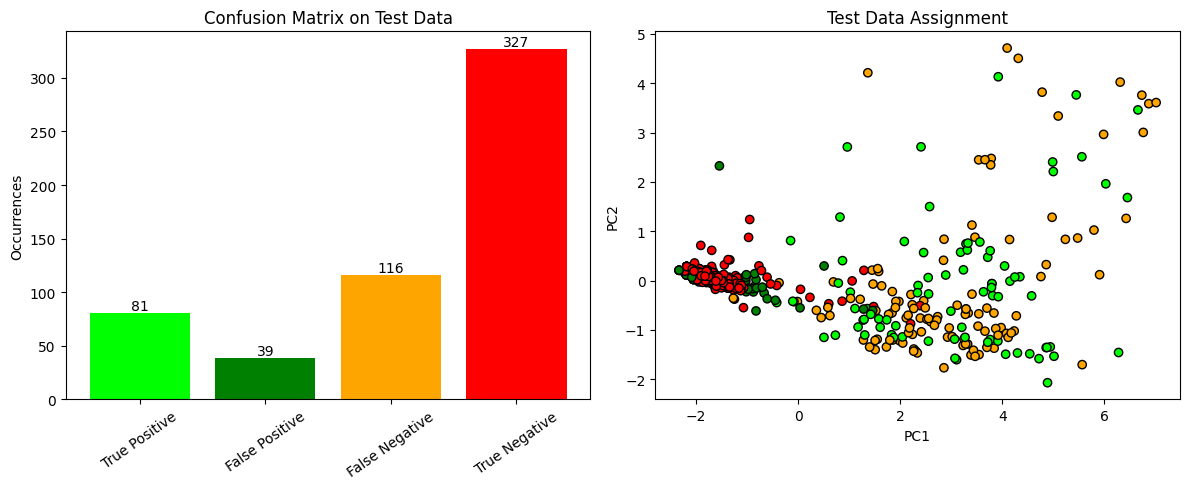

,Accuracy,Precision,True Positive Rate,Specificity,False Positive Rate
metrics,0.724689,0.675,0.411168,0.893443,0.106557


In [ ]:
# Plotting Confusion Matrix Data
QNN.confusion_matrix(xlabel = "feature_1", ylabel = "feature_2", vertical = False)


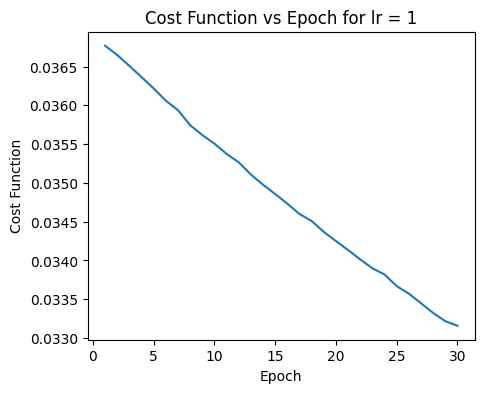

In [8]:
# Plotting the cost function as a function of epoch
QNN.learning_graph()

# Training Perceptron Neural Network using Tensorflow


Here, we implement a binary classifier via classical machine learning methods. In particular, we employ a perceptron neural network using the Tensorflow package. First, we build our classifier using two input neurons, one output neuron, and a sigmoid activation function. We use 'binary_crossentropy' for our loss function, since it is typically appropriate to use in classification tasks. And, we use stochastic gradient descent as our optimizer. 

In [8]:
# Building Perceptron Neural Network
model = Sequential()
model.add(Dense(units = 2 , activation= 'sigmoid'))
model.add(Dense(units = 1 , activation= 'sigmoid'))

# Specifying loss function and Training Method
model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])

# Training CNN
model.fit(x_train, binary_targets_train, epochs=100, batch_size= 1)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8634 - loss: 0.6429
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9084 - loss: 0.5272
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9286 - loss: 0.4415
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9400 - loss: 0.3815
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9860 - loss: 0.3215
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9703 - loss: 0.2974
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9486 - loss: 0.2802
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9732 - loss: 0.2605
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9723 - loss: 0.2404
Epoch 10/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9635 - loss: 0.2208
Epoch 11/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9918 - loss: 0.1963
Epoch 12/100
120/120 ━━━━━━━━━━━━━━━━━━━━

In [9]:
# Assessing model predictions on test data
model_prediction = model.predict(x_test)


# Printing Model Prediction Output
print(model_prediction)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[[0.01336046]
 [0.02064206]
 [0.9741629 ]
 [0.9732644 ]
 [0.9739192 ]
 [0.02938658]
 [0.9732376 ]
 [0.0128963 ]
 [0.97415924]
 [0.01989192]
 [0.0128963 ]
 [0.01424474]
 [0.01712959]
 [0.01504597]
 [0.15768588]
 [0.87559897]
 [0.9739357 ]
 [0.01597947]
 [0.8317699 ]
 [0.9741176 ]
 [0.0128963 ]
 [0.97405034]
 [0.97224784]
 [0.01505178]
 [0.52278364]
 [0.97372526]
 [0.01388326]
 [0.9709053 ]
 [0.79235613]
 [0.01617185]
 [0.9741325 ]
 [0.0245558 ]
 [0.01469059]
 [0.01494323]
 [0.01356408]
 [0.01403332]
 [0.01587641]
 [0.97249466]
 [0.01591614]
 [0.01370865]
 [0.0147379 ]
 [0.9738798 ]
 [0.97416306]
 [0.9716309 ]
 [0.02616075]
 [0.97403204]
 [0.9740363 ]
 [0.9705522 ]
 [0.01528201]
 [0.01539621]
 [0.01476652]
 [0.01403332]
 [0.9731432 ]
 [0.97339475]
 [0.0162855 ]
 [0.9688055 ]
 [0.9740282 ]
 [0.0142412 ]
 [0.01871217]
 [0.01590494]
 [0.97416055]
 [0.01527501]
 [0.97362596]
 [0.0128963 ]
 [0.01366355]
 [0.01587641]
 [0.04230167]
 [0.02918286]
 [0.90433

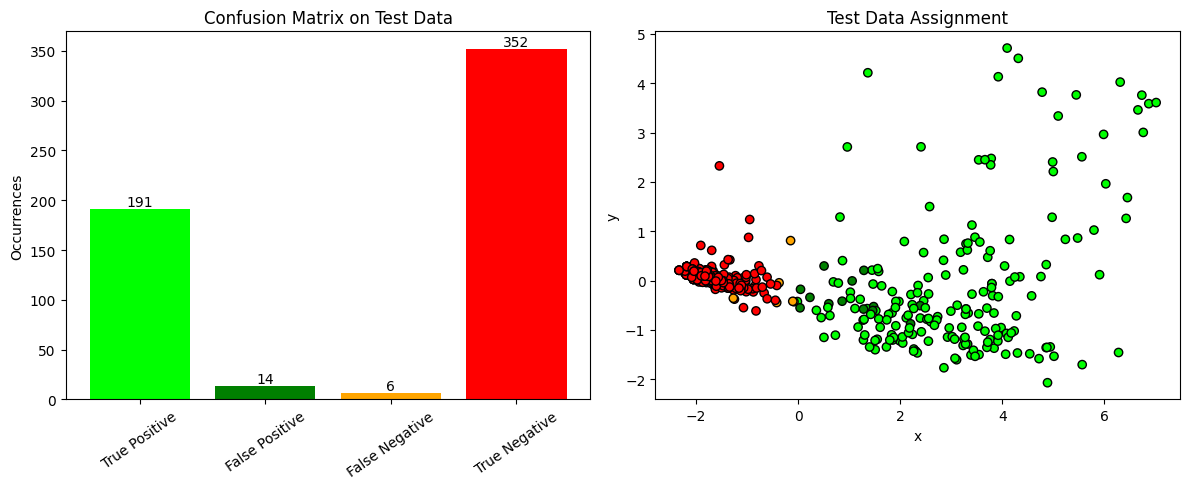

,Accuracy,Precision,True Positive Rate,Specificity,False Positive Rate
metrics,0.964476,0.931707,0.969543,0.961749,0.038251


In [10]:
# Plotting Confusion Matrix Data
nn_confusion(model_prediction, binary_targets_test, x_test)